# 教学案例：FCN-32s 语义分割（基于 PASCAL VOC）

### 知识点简介：什么是 FCN？
**FCN (Fully Convolutional Networks)** 是语义分割领域的里程碑式作品。它最大的创新是将分类网络（如 VGG, ResNet）最后的 **全连接层（FC）** 替换为了 **卷积层**。

*   **全卷积化**：允许网络接受任意尺寸的输入，并输出与之大小匹配的特征图（Heatmap）。
*   **端到端（End-to-End）**：直接实现从像素到像素的分类。

### 设计程序的意义
通过本程序，学生可以掌握：
1.  如何将传统的分类网络（Backbone）改造为分割网络。
2.  理解“上采样”（Upsampling/Deconvolution）的概念。
3.  掌握语义分割特有的评价指标：**mIoU**。

---

### 网络结构与 32s 过程详解
1.  **Backbone (骨干网络)**：本案例使用 **VGG-16** 作为特征提取器。输入图像经过 5 组卷积池化，尺寸缩小为原来的 $1/32$。
2.  **Score Layer**：将深层的特征通道数转换为类别数（VOC 为 21 类）。
3.  **32s 的由来**：在最深层的特征层上，直接使用一个步长（Stride）为 **32** 的转置卷积（Transposed Conv）将特征图放大 32 倍，恢复到原图大小。
    *   **公式**：$Output = (Input - 1) \times 32 + Kernel - 2 \times Padding$

In [7]:
import os
import os.path as osp
import collections
import numpy as np
import PIL.Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils import data
import matplotlib.pyplot as plt
from IPython.display import clear_output

# 默认优先使用 GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"GPU is available. Using device: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("GPU is not available. Falling back to CPU.")


GPU is available. Using device: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 1. 数据集解读：PASCAL VOC

PASCAL VOC 2012 包含 20 个前景类别和 1 个背景类别。
而在标注图（Label）中，每个像素的值代表了它的类别索引值。

### 类别与颜色对照表 (Standard VOC Palette)
| 索引 | 类别 | 视觉颜色 (标准) | 索引 | 类别 | 视觉颜色 (标准) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 0 | 背景 | 黑色 (0,0,0) | 11 | 餐桌 | 橙色 (192,128,0) |
| 1 | 飞机 | 暗红色 (128,0,0) | 12 | 狗 | 深蓝色 (64,0,128) |
| 2 | 自行车 | 暗绿色 (0,128,0) | 13 | 马 | 品红色 (192,0,128) |
| 3 | 鸟 | 橄榄色 (128,128,0) | 14 | 摩托车 | 青色 (64,128,128) |
| 4 | 船 | 深蓝色 (0,0,128) | 15 | **人** | 浅红色 (192,128,128) |
| 5 | 瓶子 | 紫色 (128,0,128) | 16 | 盆栽 | 森林绿 (0,64,0) |
| 6 | 巴士 | 青色 (0,128,128) | 17 | 羊 | 褐色 (128,64,0) |
| 7 | 汽车 | 灰色 (128,128,128) | 18 | 沙发 | 绿色 (0,192,0) |
| 8 | 猫 | 酒红色 (64,0,0) | 19 | 火车 | 浅绿色 (128,192,0) |
| 9 | 椅子 | 红色 (192,0,0) | 20 | 电视/显示器 | 蓝色 (0,64,128) |
| 10 | 牛 | 黄绿色 (64,128,0) | 255 | 边界区 | 白色 (忽略计算) |

**教学注意**：在可视化时，默认的 `imshow` (如 viridis 调色板) 颜色可能与标准 VOC 颜色不同（例如 15 号的人在默认情况下可能是黄色，而背景是深紫色）。只要 **索引值一致**，位置重合，模型预测就是正确的。


In [8]:
class VOCClassSegBase(data.Dataset):
    class_names = np.array([
        'background', 'aeroplane', 'bicycle', 'bird', 'boat',
        'bottle', 'bus', 'car', 'cat', 'chair',
        'cow', 'diningtable', 'dog', 'horse', 'motorbike',
        'person', 'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor',
    ])
    mean_bgr = np.array([104.00698793, 116.66876762, 122.67891434])

    def __init__(self, root, split='train', transform=False):
        self.root = root
        self.split = split
        self._transform = transform

        dataset_dir = osp.join(self.root, 'VOC/VOCdevkit/VOC2012')
        self.files = collections.defaultdict(list)
        for s in ['train', 'val']:
            imgsets_file = osp.join(dataset_dir, 'ImageSets/Segmentation/%s.txt' % s)
            for did in open(imgsets_file):
                did = did.strip()
                img_file = osp.join(dataset_dir, 'JPEGImages/%s.jpg' % did)
                lbl_file = osp.join(dataset_dir, 'SegmentationClass/%s.png' % did)
                self.files[s].append({'img': img_file, 'lbl': lbl_file})

 
        # 数据集 20% 子集采样划分逻辑 (可以通过取消/添加注释来切换)
        # 这里的实现逻辑是独立的，采样时会同时选取对应的图像和标注文件
        subset_ratio = 0.2
        n_total = len(self.files[self.split])
        n_subset = max(1, int(n_total * subset_ratio))
        # 使用固定随机种子 42 确保训练和验证集抽取的稳定性
        indices = np.random.RandomState(42).permutation(n_total)[:n_subset]
        self.files[self.split] = [self.files[self.split][i] for i in indices]
        print(f"[{self.split}] 模式: 已启用 20% 子集采样, 样本数: {len(self.files[self.split])}/{n_total}")


    def __len__(self):
        return len(self.files[self.split])

    def __getitem__(self, index):
        data_file = self.files[self.split][index]
        img = PIL.Image.open(data_file['img'])
        img = np.array(img, dtype=np.uint8)
        lbl = PIL.Image.open(data_file['lbl'])
        lbl = np.array(lbl, dtype=np.int32)
        lbl[lbl == 255] = -1
        if self._transform:
            return self.transform(img, lbl)
        else:
            return img, lbl

    def transform(self, img, lbl):
        img = img[:, :, ::-1]  # RGB -> BGR
        img = img.astype(np.float64)
        img -= self.mean_bgr
        img = img.transpose(2, 0, 1) # HWC -> CHW
        img = torch.from_numpy(img).float()
        lbl = torch.from_numpy(lbl).long()
        return img, lbl

    def untransform(self, img, lbl):
        img = img.numpy().transpose(1, 2, 0)
        img += self.mean_bgr
        img = img.astype(np.uint8)[:, :, ::-1] # BGR -> RGB
        lbl = lbl.numpy()
        return img, lbl

def custom_collate_fn(batch):
    images, labels = [], []
    for img, lbl in batch:
        lbl_clean = lbl.clone()
        lbl_clean[(lbl_clean < 0) | (lbl_clean > 255)] = 255
        images.append(img)
        labels.append(lbl_clean)
    
    max_h = max([img.shape[1] for img in images])
    max_w = max([img.shape[2] for img in images])
    
    padded_images, padded_labels = [], []
    for img, label in zip(images, labels):
        h, w = img.shape[1], img.shape[2]
        pad_h, pad_w = max_h - h, max_w - w
        if pad_h > 0 or pad_w > 0:
            img = torch.nn.functional.pad(img.unsqueeze(0), (0, pad_w, 0, pad_h), value=0).squeeze(0)
            label = torch.nn.functional.pad(label.unsqueeze(0).unsqueeze(0), (0, pad_w, 0, pad_h), value=255).squeeze(0).squeeze(0)
        padded_images.append(img)
        padded_labels.append(label)
    
    return torch.stack(padded_images), torch.stack(padded_labels)


## 2. 模型定义：从分类到分割的转变

在本节中，我们定义 **FCN-32s** 网络。它是对经典图像分类网络 **VGG-16** 的改造，核心理念可以总结为：

### 2.1 骨干网络 (Backbone): VGG-16
*   **VGG-16** 的结构由一系列卷积层和池化层组成。
*   **下采样（Downsampling）**：经过 5 次最大的池化（MaxPool），特征图的尺寸每次减半值，最终变为原图的 $1/2^5 = 1/32$。
*   **感受野（Receptive Field）**：浅层卷积捕获纹理等低级特征，深层卷积捕获物体形状等高级语义特征。

### 2.2 全卷积化 (Transition to Fully Convolutional)
*   在分类网络中，VGG-16 最后会接全连接层。在 FCN 中，我们将这些全连接层替换成了 **1x1 或 7x7 的卷积层**。
*   **优点**：这使得网络可以接受任意尺寸的输入，并保留了空间信息。

### 2.3 上采样 (Upsampling / Deconvolution)
*   **32s 的核心步值骤**：将最后一层（Pool5 后）的特征图直接通过一个 `ConvTranspose2d`（转置卷积），并设置步长 `stride=32`。
*   **双线性插值初始化**：为了让网络获得更好的起点，我们通常使用双线性插值（Bilinear Interpolation）算法来初始化转置卷积的权重。

### 2.4 裁剪与对齐 (Cropping and Alignment)
*   由于 VGG 原版网络中第一层卷积加入了较大的 Padding（100），导致输出特征图在反卷积后会比原图略大。
*   我们在 `forward` 函数中最后一步进行 **中心裁剪（Crop）**，确保输出的 Mask（掩码）与输入图片在像素上一一对应。


In [9]:
def get_upsampling_weight(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    center = factor - 1 if kernel_size % 2 == 1 else factor - 0.5
    og = np.ogrid[:kernel_size, :kernel_size]
    filt = (1 - abs(og[0] - center) / factor) * (1 - abs(og[1] - center) / factor)
    weight = np.zeros((in_channels, out_channels, kernel_size, kernel_size), dtype=np.float64)
    weight[range(in_channels), range(out_channels), :, :] = filt
    return torch.from_numpy(weight).float()

class FCN32s(nn.Module):
    def __init__(self, n_class=21):
        super(FCN32s, self).__init__()
        # conv1
        self.conv1_1 = nn.Conv2d(3, 64, 3, padding=100)
        self.relu1_1 = nn.ReLU(inplace=True)
        self.conv1_2 = nn.Conv2d(64, 64, 3, padding=1)
        self.relu1_2 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2, stride=2, ceil_mode=True)
        # conv2
        self.conv2_1 = nn.Conv2d(64, 128, 3, padding=1)
        self.relu2_1 = nn.ReLU(inplace=True)
        self.conv2_2 = nn.Conv2d(128, 128, 3, padding=1)
        self.relu2_2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(2, stride=2, ceil_mode=True)
        # conv3
        self.conv3_1 = nn.Conv2d(128, 256, 3, padding=1)
        self.relu3_1 = nn.ReLU(inplace=True)
        self.conv3_2 = nn.Conv2d(256, 256, 3, padding=1)
        self.relu3_2 = nn.ReLU(inplace=True)
        self.conv3_3 = nn.Conv2d(256, 256, 3, padding=1)
        self.relu3_3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(2, stride=2, ceil_mode=True)
        # conv4
        self.conv4_1 = nn.Conv2d(256, 512, 3, padding=1)
        self.relu4_1 = nn.ReLU(inplace=True)
        self.conv4_2 = nn.Conv2d(512, 512, 3, padding=1)
        self.relu4_2 = nn.ReLU(inplace=True)
        self.conv4_3 = nn.Conv2d(512, 512, 3, padding=1)
        self.relu4_3 = nn.ReLU(inplace=True)
        self.pool4 = nn.MaxPool2d(2, stride=2, ceil_mode=True)
        # conv5
        self.conv5_1 = nn.Conv2d(512, 512, 3, padding=1)
        self.relu5_1 = nn.ReLU(inplace=True)
        self.conv5_2 = nn.Conv2d(512, 512, 3, padding=1)
        self.relu5_2 = nn.ReLU(inplace=True)
        self.conv5_3 = nn.Conv2d(512, 512, 3, padding=1)
        self.relu5_3 = nn.ReLU(inplace=True)
        self.pool5 = nn.MaxPool2d(2, stride=2, ceil_mode=True)
        # fc6
        self.fc6 = nn.Conv2d(512, 4096, 7)
        self.relu6 = nn.ReLU(inplace=True)
        self.drop6 = nn.Dropout2d()
        # fc7
        self.fc7 = nn.Conv2d(4096, 4096, 1)
        self.relu7 = nn.ReLU(inplace=True)
        self.drop7 = nn.Dropout2d()
        self.score_fr = nn.Conv2d(4096, n_class, 1)
        self.upscore = nn.ConvTranspose2d(n_class, n_class, 64, stride=32, bias=False)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                m.weight.data.zero_()
                if m.bias is not None:
                    m.bias.data.zero_()
            if isinstance(m, nn.ConvTranspose2d):
                m.weight.data.copy_(get_upsampling_weight(m.in_channels, m.out_channels, m.kernel_size[0]))

    def forward(self, x):
        h = x
        h = self.relu1_1(self.conv1_1(h))
        h = self.relu1_2(self.conv1_2(h))
        h = self.pool1(h)
        h = self.relu2_1(self.conv2_1(h))
        h = self.relu2_2(self.conv2_2(h))
        h = self.pool2(h)
        h = self.relu3_1(self.conv3_1(h))
        h = self.relu3_2(self.conv3_2(h))
        h = self.relu3_3(self.conv3_3(h))
        h = self.pool3(h)
        h = self.relu4_1(self.conv4_1(h))
        h = self.relu4_2(self.conv4_2(h))
        h = self.relu4_3(self.conv4_3(h))
        h = self.pool4(h)
        h = self.relu5_1(self.conv5_1(h))
        h = self.relu5_2(self.conv5_2(h))
        h = self.relu5_3(self.conv5_3(h))
        h = self.pool5(h)
        h = self.relu6(self.fc6(h))
        h = self.drop6(h)
        h = self.relu7(self.fc7(h))
        h = self.drop7(h)
        h = self.score_fr(h)
        h = self.upscore(h)
        # 裁剪对齐原图
        h = h[:, :, 19:19 + x.size()[2], 19:19 + x.size()[3]].contiguous()
        return h

## 3. 核心评估指标：mIoU (Mean Intersection over Union)

在每一轮训练结束后，我们需要评估模型的效果。不同于普通的分类任务，语义分割不仅要看像素分对了多少，更看重预测区域和真实标注区域之间的重合度。

*   **Intersection (交集)**：预测为 A 且真实为 A 的像素。
*   **Union (并集)**：预测为 A **或** 真实为 A 的像素。
*   **mIoU**：计算 21 个类别的 IoU 后取平均。**如果不重合，或类别对错，IoU 都会显著下降。**

In [10]:
def decode_segmap(label_mask, n_classes=21):
    """
    将类别索引映射为标准的 VOC RGB 颜色。
    """
    label_colors = np.array([
        [0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0], [0, 0, 128],
        [128, 0, 128], [0, 128, 128], [128, 128, 128], [64, 0, 0], [192, 0, 0],
        [64, 128, 0], [192, 128, 0], [64, 0, 128], [192, 0, 128], [64, 128, 128],
        [192, 128, 128], [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
        [0, 64, 128]
    ])
    
    r = np.zeros_like(label_mask).astype(np.uint8)
    g = np.zeros_like(label_mask).astype(np.uint8)
    b = np.zeros_like(label_mask).astype(np.uint8)
    
    for l in range(0, n_classes):
        idx = (label_mask == l)
        r[idx] = label_colors[l, 0]
        g[idx] = label_colors[l, 1]
        b[idx] = label_colors[l, 2]
        
    # 处理 ignore_index (255) 或边界，通常设为白色或特定灰色
    r[label_mask == 255] = 224
    g[label_mask == 255] = 224
    b[label_mask == 255] = 192
    
    rgb = np.stack([r, g, b], axis=2)
    return rgb

def visualize_results(images, targets, preds, n_show=3):
    """
    增强版可视化：
    1. Original Image: 真实的 RGB 图像。
    2. Ground Truth (Colored): 使用 VOC 标准颜色映射的标签。
    3. Prediction (Colored): 使用 VOC 标准颜色映射的模型预测。
    """
    fig, axes = plt.subplots(n_show, 3, figsize=(15, 5 * n_show))
    for i in range(min(n_show, len(images))):
        # 1. 恢复原始图像 (Back to RGB)
        it = images[i].cpu().numpy().transpose(1, 2, 0)
        it = (it + [104.00698793, 116.66876762, 122.67891434])[:, :, ::-1].astype(np.uint8)
        axes[i, 0].imshow(it)
        axes[i, 0].set_title("Original Image")
        
        # 2. 映射 Ground Truth 颜色
        target_rgb = decode_segmap(targets[i].cpu().numpy())
        axes[i, 1].imshow(target_rgb)
        axes[i, 1].set_title("Ground Truth (Colored)")
        
        # 3. 映射 Prediction 颜色
        pred_rgb = decode_segmap(preds[i].cpu().numpy())
        axes[i, 2].imshow(pred_rgb)
        axes[i, 2].set_title("Prediction (Colored)")
        
    plt.tight_layout()
    plt.show()

def compute_iou(pred, target, n_class=21):
    """
    计算 mIoU。
    """
    pred = pred.cpu().numpy()
    target = target.cpu().numpy()
    iou_list = []
    for cls in range(n_class):
        p = (pred == cls)
        t = (target == cls)
        it = np.logical_and(p, t).sum()
        un = np.logical_or(p, t).sum()
        if un == 0:
            iou_list.append(1.0 if it == 0 else 0.0)
        else:
            iou_list.append(it / un)
    return np.mean(iou_list)

def get_parameters(model, bias=False):
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            yield m.bias if bias else m.weight


## 4. 初始化与预训练权重加载：迁移学习的力量

### 4.1 为什么要使用预训练权重？
语义分割是一个复杂的任务，从零开始训练（Training from Scratch）由于数据量限制和梯度消失/爆炸风险，通常收敛极慢。
*   **迁移学习**：我们加载在 ImageNet 大规模图像集上训练好的权重。这让模型在开始前就已经具备了识别“边缘、颜色、纹理”甚至“动物、车身”的基础能力。

### 4.2 处理权重格式
不同的模型发布者保存权重的方式不同。
*   有的直接保存为 `dict`。
*   有的包装在字典的 `model_state_dict` 字段下。
*   代码中通过判断字段键（Key）来进行兼容性加载。

### 4.3 优化器配置 (Optimizer)
*   **SGD (随机梯度下降)**：配合 **动量 (Momentum=0.99)** 和 **权重衰减 (Weight Decay)**。
*   **学习率差异化设置**：
    *   **权重 (Weight)**：使用基础学习率 $10^{-4}$。
    *   **偏置 (Bias)**：通常使用 2 倍的学习率，且不进行权重衰减，有助于模型更快捕捉偏移特征。

### 4.4 损失函数 (Loss Function)
*   使用 **交叉熵损失 (CrossEntropyLoss)**。
*   **ignore_index=255**：在 PASCAL VOC 中，物体边界被标注为 255（白色边缘）。这部分模糊区域我们不希望它参与损失计算，也不希望它干扰模型学习清析的物体特征。


In [11]:
root = 'data/datasets'
batch_size = 4

train_loader = data.DataLoader(
    VOCClassSegBase(root, split='train', transform=True),
    batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn, num_workers=0
)
val_loader = data.DataLoader(
    VOCClassSegBase(root, split='val', transform=True),
    batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn, num_workers=0
)

model = FCN32s(n_class=21)
weights_path = 'fcn32s-heavy-pascal.pth'

if osp.exists(weights_path):
    print(f"Loading pretrained weights from {weights_path}...")
    # 根据权重文件格式加载
    checkpoint = torch.load(weights_path, map_location='cpu')
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
else:
    print("Pretrained weights not found, training from scratch.")

model = model.to(device)

optimizer = optim.SGD([
    {'params': get_parameters(model, bias=False)},
    {'params': get_parameters(model, bias=True), 'lr': 1e-4 * 2, 'weight_decay': 0}
], lr=1e-4, momentum=0.99, weight_decay=0.0005)

criterion = nn.CrossEntropyLoss(ignore_index=255)


[train] 模式: 已启用 20% 子集采样, 样本数: 292/1464
[val] 模式: 已启用 20% 子集采样, 样本数: 289/1449
Loading pretrained weights from fcn32s-heavy-pascal.pth...


## 5. 训练循环：磨炼与验证

### 5.1 训练模式 (`model.train()`)
*   告诉 Pytorch 开启 **Dropout** 等机制。
*   **Backpropagation**：通过 `loss.backward()` 计算梯度并使用优化器更新参数。

### 5.2 验证模式 (`model.eval()`)
*   在每个 Epoch 结束时，我们切换到验证模式并使用 `torch.no_grad()`。
*   **可视化监控**：实时绘制前几张验证集图片，通过观察肉眼可见的“颜色变化”来感知模型对不同物体的识别。
*   **指标计算**：使用 `mean_iou`（mIoU）来精确量化模型的效果。

### 5.3 模型保存策略 (Checkpointing)
*   我们不保存每一轮的模型，而是只保存 **当前表现最好 (Best mIoU)** 的模型。
*   在实际教学中，建议学生观察 Loss 值是否持续下降，以及 mIoU 与可视化结果是否一致。


Epoch 2 Visualization (Running on cuda):


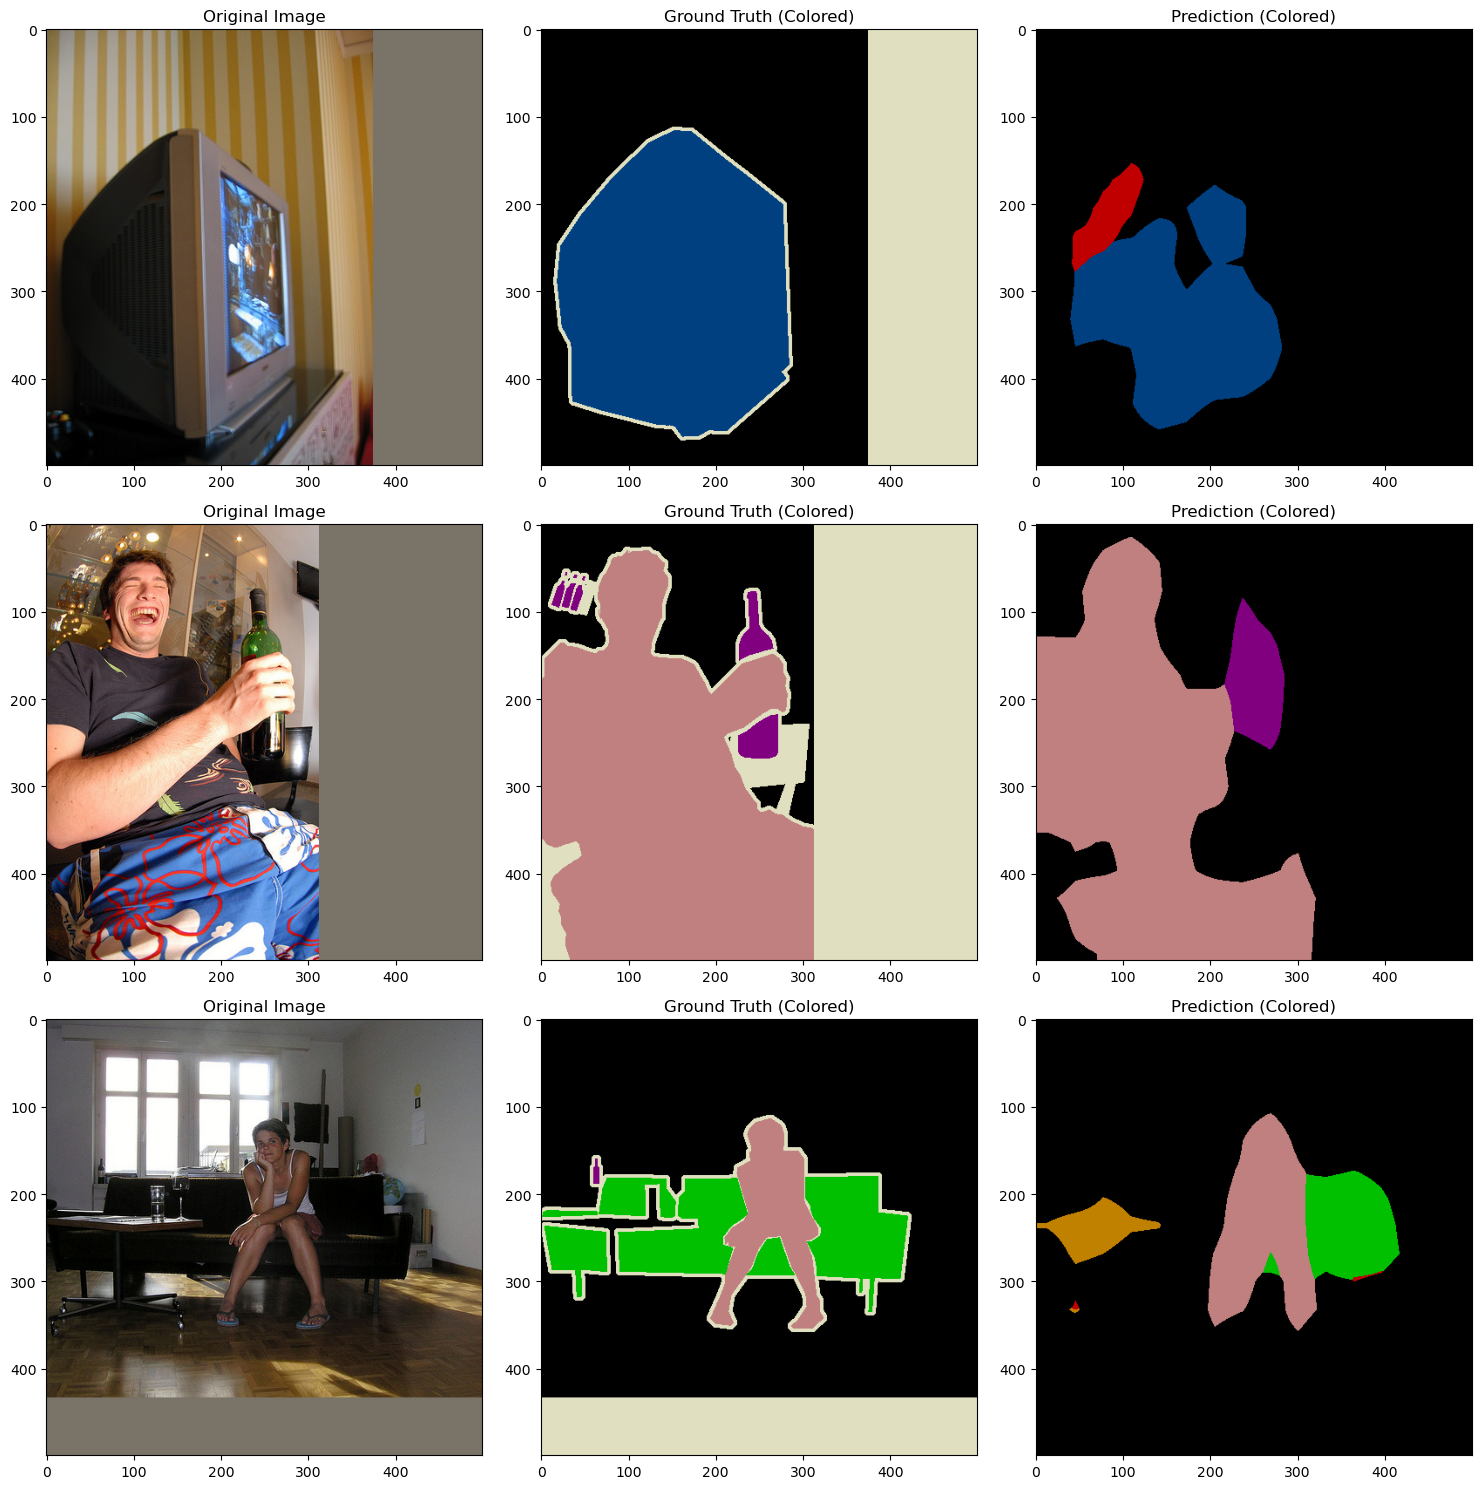

Epoch 2 Validation mIoU: 0.8079 (Device: cuda)
New best model saved with mIoU: 0.8079
Training Complete!


In [12]:
epochs = 3
best_iou = 0.0
output_best_model = 'best_fcn32s_model.pth'

print(f"Starting training on device: {device}")

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for batch_idx, (imgs, lbls) in enumerate(train_loader):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
        if batch_idx % 10 == 0:
            print(f"Epoch [{epoch}/{epochs}] Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.4f}")
    
    # 验证
    model.eval()
    val_iou = []
    with torch.no_grad():
        for i, (imgs, lbls) in enumerate(val_loader):
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            preds = out.argmax(dim=1)
            val_iou.append(compute_iou(preds, lbls))
            
            if i == 0: # 每个 Epoch 展示一次可视化结果
                clear_output(wait=True)
                print(f"Epoch {epoch} Visualization (Running on {device}):")
                visualize_results(imgs, lbls, preds)
    
    mean_iou = np.mean(val_iou)
    print(f"Epoch {epoch} Validation mIoU: {mean_iou:.4f} (Device: {device})")
    
    if mean_iou > best_iou:
        best_iou = mean_iou
        torch.save(model.state_dict(), output_best_model)
        print(f"New best model saved with mIoU: {best_iou:.4f}")
    
print("Training Complete!")


## 6. 拓展与思考 (Thought Questions)

请同学们根据刚才的训练结果思考以下问题：

### Q1：为什么 FCN-32s 的预测结果中，物体周围会有大量的“色块”（Blobs），且边缘非常粗糙？
*   **解答提示**：思考 32s 的上采样过程。
*   **思路**：FCN-32s 直接跳过了浅层的高清特征，在极低的分辨率特征图（缩小了 32 倍）上直接暴力拉伸。这就像是用乐高积木拼成圆圈，边缘必然是“马赛克”状的，无法捕捉头发、指尖等细微边缘。

### Q2：如果模型预测的颜色与标签完全对不上，但大致轮廓正确，这是为什么？
*   **解答提示**：复习每个颜色对应的“索引值”。
*   **思路**：这说明模型的 **分类** 层（Score Layer）还没训练好，它能在空间上发现那里有一个物体，但还分不清那是“狗”还是“羊”。

### Q3：如何改进 FCN-32s 的效果？
*   **解答提示**：引入 FCN-16s 或 FCN-8s。
*   **思路**：通过“跳跃连接”（Skip Connections），将浅层（Pooling 4 / Pooling 3）具有丰富像素细节的特征提取出来，与深层特征融合，帮助边缘恢复清晰。

### 课后实践：
1.  调整 `VOCClassSegBase` 中的 `subset_ratio`，尝试使用更多数据进行训练。
2.  尝试修改 `FCN32s` 的代码，增加一个跳跃连接，实现 `FCN-16s`。